<a href="https://colab.research.google.com/github/ayesha0859/DL/blob/main/GAN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
import numpy as np
import matplotlib.pyplot as plt

tf.random.set_seed(42)
np.random.seed(42)

(X_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

X_train = (X_train.astype('float32') - 127.5) / 127.5

image_shape = X_train.shape[1:]
data_dim = np.prod(image_shape)
X_train = X_train.reshape(X_train.shape[0], data_dim)

latent_dim = 100

def generate_real_samples(n_samples):
    ix = np.random.randint(0, X_train.shape[0], n_samples)
    X = X_train[ix]
    y = np.ones((n_samples, 1))
    return X, y

print("MNIST real data loaded and preprocessed.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
MNIST real data loaded and preprocessed.


In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers

def define_generator(latent_dim, data_dim):
    model = models.Sequential([
        tf.keras.Input(shape=(latent_dim,)),
        layers.Dense(256, activation='relu'),
        layers.Dense(512, activation='relu'),
        layers.Dense(int(data_dim), activation='tanh')
    ])
    return model

generator = define_generator(latent_dim, data_dim)
generator.summary()

print("Generator model defined.")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │        25,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       402,192 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 559,632 (2.13 MB)

 Trainable params: 559,632 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

Generator model defined.


In [5]:
def define_discriminator(data_dim):
    model = models.Sequential()
    model.add(layers.Dense(512, activation='leaky_relu', input_shape=(data_dim,)))
    model.add(layers.Dense(256, activation='leaky_relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    opt = optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt, metrics=['accuracy'])
    return model

discriminator = define_discriminator(data_dim)
discriminator.summary()

print("Discriminator model defined and compiled.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 533,505 (2.04 MB)

 Trainable params: 533,505 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

Discriminator model defined and compiled.


In [6]:
def define_gan(generator, discriminator):
    discriminator.trainable = False
    model = models.Sequential()
    model.add(generator)
    model.add(discriminator)

    opt = optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
    model.compile(loss='binary_crossentropy', optimizer=opt)
    return model

gan_model = define_gan(generator, discriminator)
gan_model.summary()

print("GAN model defined.")

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 784)            │       559,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_3 (Sequential)       │ (None, 1)              │       533,505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,093,137 (4.17 MB)

 Trainable params: 559,632 (2.13 MB)

 Non-trainable params: 533,505 (2.04 MB)

GAN model defined.


In [7]:
def generate_latent_points(latent_dim, n_samples):

    x_input = np.random.randn(latent_dim * n_samples)
    x_input = x_input.reshape(n_samples, latent_dim)
    return x_input

def train_gan(generator, discriminator, gan_model, epochs=1000, batch_size=64):
    d_loss_hist, g_loss_hist = [], []
    half_batch = batch_size // 2

    for i in range(epochs):
        X_real, y_real = generate_real_samples(half_batch)

        latent_points = generate_latent_points(latent_dim, half_batch)
        X_fake = generator.predict(latent_points, verbose=0)
        y_fake = np.zeros((half_batch, 1))

        d_loss_real, _ = discriminator.train_on_batch(X_real, y_real)
        d_loss_fake, _ = discriminator.train_on_batch(X_fake, y_fake)
        d_loss = 0.5 * (d_loss_real + d_loss_fake)

        latent_points = generate_latent_points(latent_dim, batch_size)
        y_gan = np.ones((batch_size, 1))

        g_loss = gan_model.train_on_batch(latent_points, y_gan)

        d_loss_hist.append(d_loss)
        g_loss_hist.append(g_loss)

        if (i+1) % 100 == 0:
            print(f'Epoch {i+1}/{epochs}, Discriminator Loss: {d_loss:.4f}, Generator Loss: {g_loss:.4f}')

    return d_loss_hist, g_loss_hist

print("Starting GAN training...")
disc_losses, gen_losses = train_gan(generator, discriminator, gan_model, epochs=5000, batch_size=128)
print("Training complete.")

Starting GAN training...


/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 100/5000, Discriminator Loss: 3.0151, Generator Loss: 0.0294
Epoch 200/5000, Discriminator Loss: 3.6605, Generator Loss: 0.0149
Epoch 300/5000, Discriminator Loss: 4.0528, Generator Loss: 0.0100
Epoch 400/5000, Discriminator Loss: 4.3347, Generator Loss: 0.0075
Epoch 500/5000, Discriminator Loss: 4.5564, Generator Loss: 0.0060
Epoch 600/5000, Discriminator Loss: 4.7368, Generator Loss: 0.0050
Epoch 700/5000, Discriminator Loss: 4.8917, Generator Loss: 0.0043
Epoch 800/5000, Discriminator Loss: 5.0251, Generator Loss: 0.0038
Epoch 900/5000, Discriminator Loss: 5.1428, Generator Loss: 0.0033
Epoch 1000/5000, Discriminator Loss: 5.2486, Generator Loss: 0.0030
Epoch 1100/5000, Discriminator Loss: 5.3433, Generator Loss: 0.0027
Epoch 1200/5000, Discriminator Loss: 5.4298, Generator Loss: 0.0025
Epoch 1300/5000, Discriminator Loss: 5.5097, Generator Loss: 0.0023
Epoch 1400/5000, Discriminator Loss: 5.5834, Generator Loss: 0.0021
Epoch 1500/5000, Discriminator Loss: 5.6520, Generator Lo


--- Testing Generator ---
Generated samples (first 5 of flattened data):
 [0.17992401 0.37481913 0.78883207 ... 0.3050307  0.13826895 0.05576202]


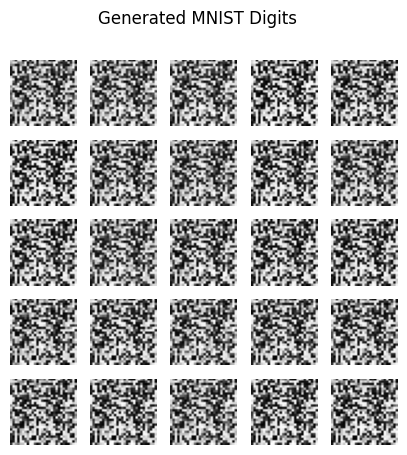

Discriminator's average prediction for generated samples: 1.0000

--- Final Training Losses ---
Final Discriminator Loss: 6.8842
Final Generator Loss: 0.0006


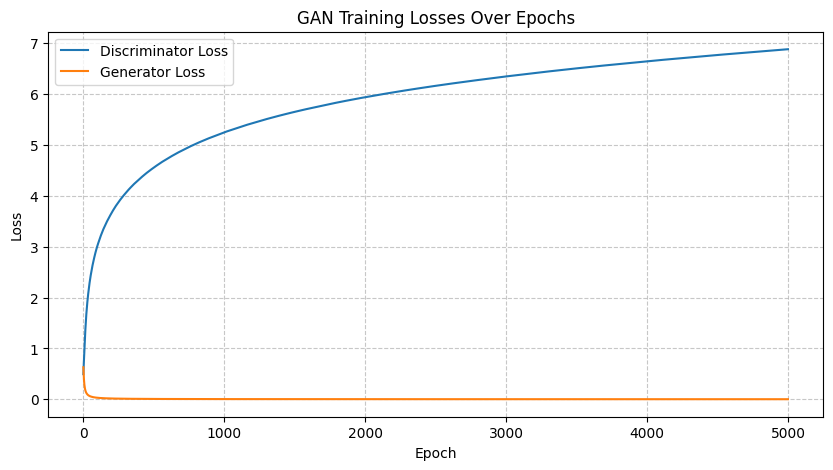

In [10]:
print("\n--- Testing Generator ---")
latent_points = generate_latent_points(latent_dim, 25)
X_generated = generator.predict(latent_points, verbose=0)

X_generated = (X_generated + 1) / 2.0

print("Generated samples (first 5 of flattened data):\n", X_generated[:5].flatten())

plt.figure(figsize=(5, 5))
for i in range(25):
    plt.subplot(5, 5, 1 + i)
    plt.axis('off')
    plt.imshow(X_generated[i].reshape(image_shape[0], image_shape[1]), cmap='gray_r')
plt.suptitle('Generated MNIST Digits')
plt.show()

predictions = discriminator.predict((X_generated * 2.0) - 1.0, verbose=0)
mean_prediction = np.mean(predictions)
print(f"Discriminator's average prediction for generated samples: {mean_prediction:.4f}")

print("\n--- Final Training Losses ---")
print(f"Final Discriminator Loss: {disc_losses[-1]:.4f}")
print(f"Final Generator Loss: {gen_losses[-1]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(disc_losses, label='Discriminator Loss')
plt.plot(gen_losses, label='Generator Loss')
plt.title('GAN Training Losses Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()